#### Assignment 2
**Mahshid Bargahi**

In this notebook, we use **Ames Housing dataset**, which contains information about samples with various features (price, technical specifications, categories, etc.).

The goal of this project is to build a **Multiclass Classification model** that predicts which price category each sample belongs to among 4 classes:
- **Very Low**
- **Low**
- **Medium**
- **High**

The model uses various features from the dataset to predict the price category of each sample.

## Libraries

In [2]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

## Loading dataset

This dataset is the cleaned and feature‑engineered version from Assignment 1. Missing values were handled, useless columns removed, and new features (ratios, binning, date/time transformations, aggregations, and log transforms) were created. All categorical variables were encoded.

In [3]:
data  = pd.read_csv(r'D:\sharif\ADS\assignments\assignment2\AmesHousing_Encoded_Final.csv')
print(data.shape)
data.head()

(2854, 174)


,MS SubClass,Lot Frontage,Lot Area,Land Slope,Condition 1,Condition 2,Overall Qual,Overall Cond,Year Remod/Add,Mas Vnr Area,...,Garage Type_None,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
0,20,141.0,31770,1,6,5,6,5,1960,112.0,...,0,0,0,0,0,0,0,0,0,1
1,20,80.0,11622,1,4,5,5,6,1961,1.0,...,0,0,0,0,0,0,0,0,0,1
2,20,81.0,14267,1,6,5,6,6,1958,108.0,...,0,0,0,0,0,0,0,0,0,1
3,20,93.0,11160,1,6,5,7,5,1968,1.0,...,0,0,0,0,0,0,0,0,0,1
4,60,74.0,13830,1,6,5,5,5,1998,1.0,...,0,0,0,0,0,0,0,0,0,1


Unlike binary classification, for multiclass we must split the data **first**, then create the target bins **only from the training set**.  
This ensures that the quartiles are defined purely by training data, and the test set is labeled using those same bins — preventing data leakage.

### Removing Data Leakage Features
To prevent the model from cheating, features that are directly or indirectly derived from SalePrice must be removed.

We removed columns (which leak information), but **kept SalePrice** as the target.

In [4]:
price_related_cols = [col for col in data.columns if ('price' in col.lower() or 'avgprice' in col.lower()) and col != 'SalePrice']
data = data.drop(columns=price_related_cols, errors='ignore')
print(data.shape)

(2854, 171)


## Splitting data

In [5]:
X  = data.drop('SalePrice', axis=1)
y = data['SalePrice']

X.head()

,MS SubClass,Lot Frontage,Lot Area,Land Slope,Condition 1,Condition 2,Overall Qual,Overall Cond,Year Remod/Add,Mas Vnr Area,...,Garage Type_None,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
0,20,141.0,31770,1,6,5,6,5,1960,112.0,...,0,0,0,0,0,0,0,0,0,1
1,20,80.0,11622,1,4,5,5,6,1961,1.0,...,0,0,0,0,0,0,0,0,0,1
2,20,81.0,14267,1,6,5,6,6,1958,108.0,...,0,0,0,0,0,0,0,0,0,1
3,20,93.0,11160,1,6,5,7,5,1968,1.0,...,0,0,0,0,0,0,0,0,0,1
4,60,74.0,13830,1,6,5,5,5,1998,1.0,...,0,0,0,0,0,0,0,0,0,1


In [6]:
y.head()

0    215000
1    105000
2    172000
3    244000
4    189900
Name: SalePrice, dtype: int64

### Preparing Train and Test Sets

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(2283, 170)
(571, 170)


## Creating Multiclass Target

For the multiclass classification task, we transformed the continuous **SalePrice** into **four discrete price categories**.  

| Category | Price Range | Meaning |
|----------|-------------|---------|
| Very Low | < 25th percentile | Very cheap houses |
| Low | 25th – 50th percentile | Below‑average price |
| Medium | 50th – 75th percentile | Above‑average price |
| High | > 75th percentile | Expensive / luxury houses |

In [8]:
price_bins = [0, y_train.quantile(0.25), y_train.quantile(0.5), y_train.quantile(0.75), y_train.max()]
labels = ['Very Low', 'Low', 'Medium', 'High']

y_train_multi = pd.cut(y_train, bins=price_bins, labels=labels)
y_test_multi = pd.cut(y_test, bins=price_bins, labels=labels)

In [9]:
y_train_multi[:10]

1411         Low
2711    Very Low
841          Low
651     Very Low
2215        High
1623    Very Low
670     Very Low
1702        High
1106        High
2462        High
Name: SalePrice, dtype: category
Categories (4, object): ['Very Low' < 'Low' < 'Medium' < 'High']

### Visualizing the Multiclass Target (getting some insight)

C:\Users\kavoshrayan\AppData\Local\Temp\ipykernel_22320\1942287805.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_multi, palette='Set2', order=['Very Low', 'Low', 'Medium', 'High'])


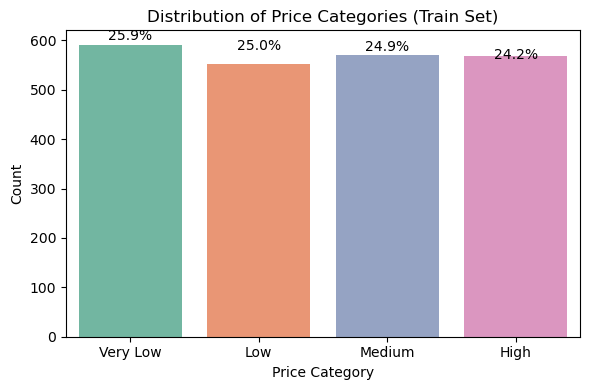

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_multi, palette='Set2', order=['Very Low', 'Low', 'Medium', 'High'])
plt.title('Distribution of Price Categories (Train Set)')
plt.xlabel('Price Category')
plt.ylabel('Count')
for i, v in enumerate(y_train_multi.value_counts().values):
    plt.text(i, v + 10, f'{v/len(y_train_multi)*100:.1f}%', ha='center')
plt.tight_layout()
plt.show()

- Class distribution is **balanced** (~25% per category), which is good for multiclass classification.

C:\Users\kavoshrayan\AppData\Local\Temp\ipykernel_22320\1874018533.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_class = plot_df.groupby('Price_Category')[important_features].mean().reindex(['Very Low', 'Low', 'Medium', 'High'])


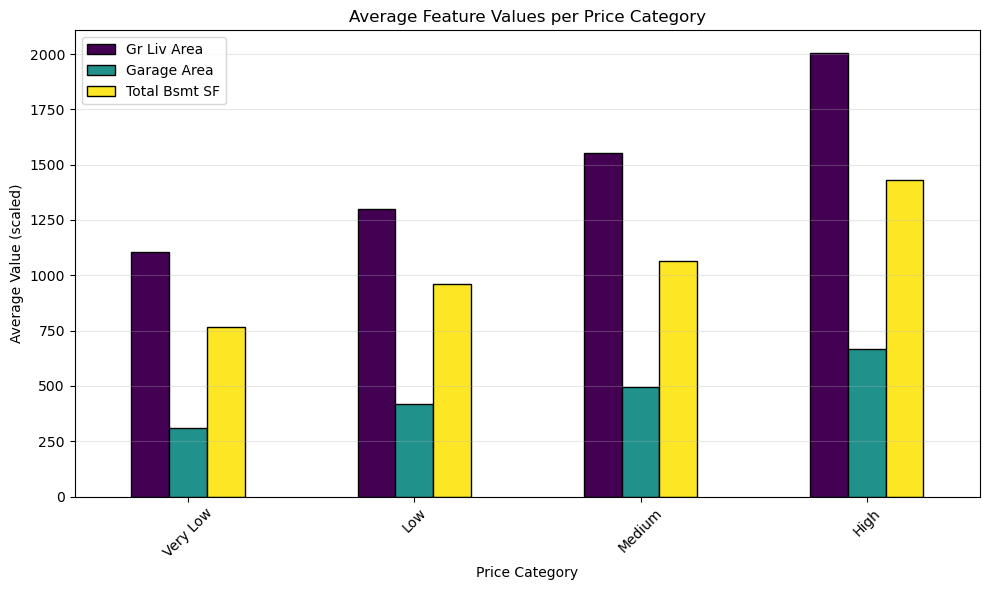

In [11]:
important_features = ['Gr Liv Area', 'Garage Area', 'Total Bsmt SF']

plot_df = X_train.copy()
plot_df['Price_Category'] = y_train_multi

# mean of each feature in each class
mean_by_class = plot_df.groupby('Price_Category')[important_features].mean().reindex(['Very Low', 'Low', 'Medium', 'High'])

mean_by_class.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.title('Average Feature Values per Price Category')
plt.xlabel('Price Category')
plt.ylabel('Average Value (scaled)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Features like **Gr Liv Area** and **Garage Area** increase consistently from *Very Low* to *High* price categories.

## Preprocessing

### Scaling 

**Scale** features using StandardScaler
   - fit on training set only
   - transform on both training and test sets


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
X_train_scaled_df = pd.DataFrame(X_train, columns=X.columns)
X_train_scaled_df .describe()

,MS SubClass,Lot Frontage,Lot Area,Land Slope,Condition 1,Condition 2,Overall Qual,Overall Cond,Year Remod/Add,Mas Vnr Area,...,Garage Type_None,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
count,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,...,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03,2.283000e+03
mean,-2.178624e-17,-3.890400e-17,-9.336961e-17,2.474295e-16,-1.882954e-16,9.741563e-16,2.925581e-16,-3.633634e-16,5.138635e-15,-1.478352e-17,...,-4.668481e-17,7.780801e-19,1.089312e-17,-1.244928e-17,2.334240e-17,6.224641e-18,3.034512e-17,2.023008e-17,-3.112320e-18,-3.073416e-17
std,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,...,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00,1.000219e+00
min,-8.754653e-01,-2.306707e+00,-1.231990e+00,-2.199232e-01,-4.372752e+00,-1.630418e+01,-3.677732e+00,-4.130178e+00,-1.657750e+00,-5.786150e-01,...,-2.303134e-01,-6.291092e-02,-3.627381e-02,-9.400971e-02,-5.545783e-02,-5.929995e-02,-3.047415e-01,-5.545783e-02,-2.093352e-02,-2.508771e+00
25%,-8.754653e-01,-4.347796e-01,-3.425040e-01,-2.199232e-01,2.413138e-01,3.399313e-02,-7.983554e-01,-5.091348e-01,-8.883376e-01,-5.786150e-01,...,-2.303134e-01,-6.291092e-02,-3.627381e-02,-9.400971e-02,-5.545783e-02,-5.929995e-02,-3.047415e-01,-5.545783e-02,-2.093352e-02,3.986016e-01
50%,-1.756448e-01,4.520194e-02,-7.329841e-02,-2.199232e-01,2.413138e-01,3.399313e-02,-7.851125e-02,-5.091348e-01,4.100457e-01,-5.786150e-01,...,-2.303134e-01,-6.291092e-02,-3.627381e-02,-9.400971e-02,-5.545783e-02,-5.929995e-02,-3.047415e-01,-5.545783e-02,-2.093352e-02,3.986016e-01
75%,2.909022e-01,5.251835e-01,2.251155e-01,-2.199232e-01,2.413138e-01,3.399313e-02,6.413329e-01,3.961259e-01,9.390167e-01,3.718926e-01,...,-2.303134e-01,-6.291092e-02,-3.627381e-02,-9.400971e-02,-5.545783e-02,-5.929995e-02,-3.047415e-01,-5.545783e-02,-2.093352e-02,3.986016e-01
max,3.090184e+00,1.170875e+01,2.955112e+01,4.678463e+00,3.009754e+00,1.228762e+01,2.800865e+00,3.111908e+00,1.227546e+00,7.451133e+00,...,4.341909e+00,1.589549e+01,2.756810e+01,1.063720e+01,1.803172e+01,1.686342e+01,3.281469e+00,1.803172e+01,4.777028e+01,3.986016e-01


## Modeling

In [ ]:
# Evaluate a multiclass classification model with all required metrics.

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report


def evaluate_multiclass_model(model_name, y_test, y_pred):
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Precision, Recall, F1 per class (macro, micro, weighted)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(y_test, y_pred, average='micro')
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    unique_labels = np.unique(y_test)
    # Per-class metrics 
    per_class = precision_recall_fscore_support(y_test, y_pred, average=None, labels=unique_labels)
    
    print(f" {model_name}")
    print(f"Accuracy              : {acc:.4f}")
    print(f"\nF1 Score (Macro)      : {f1_macro:.4f}")
    print(f"F1 Score (Micro)      : {f1_micro:.4f}")
    print(f"F1 Score (Weighted)   : {f1_weighted:.4f}")
    print(f"\nPrecision (Macro)     : {precision_macro:.4f}")
    print(f"Recall (Macro)        : {recall_macro:.4f}")
    
    # per-class
    print("\n Per-Class Performance:")
    for i, cls in enumerate(unique_labels):
        print(f"   {cls}: Precision={per_class[0][i]:.4f}, Recall={per_class[1][i]:.4f}, F1={per_class[2][i]:.4f}")
    
    # Return all metrics as dict
    return {
        'Model': model_name,
        'Accuracy': acc,
        'F1_Macro': f1_macro,
        'F1_Micro': f1_micro,
        'F1_Weighted': f1_weighted,
        'Precision_Macro': precision_macro,
        'Recall_Macro': recall_macro
    }

### SVM
I use decision_function_shape='ovr' because :

- The number of classes is 4 → both OVR and OVO are viable.
- OVR trains one model per class (faster) and is more interpretable.
- OVO would train 6 models, which is slower and less necessary given the near‑linear nature of the data.

In [67]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', decision_function_shape='ovr', max_iter=1000, random_state=42)
svm_model.fit(X_train, y_train_multi)
y_pred_svm = svm_model.predict(X_test)

svm_performance = evaluate_multiclass_model("SVM", y_test_multi, y_pred_svm)

 SVM
Accuracy              : 0.7233

F1 Score (Macro)      : 0.7188
F1 Score (Micro)      : 0.7233
F1 Score (Weighted)   : 0.7223

Precision (Macro)     : 0.7177
Recall (Macro)        : 0.7216

 Per-Class Performance:
   High: Precision=0.8543, Recall=0.8543, F1=0.8543
   Low: Precision=0.6241, Recall=0.5646, F1=0.5929
   Medium: Precision=0.6391, Recall=0.7143, F1=0.6746
   Very Low: Precision=0.7532, Recall=0.7532, F1=0.7532


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [68]:
svm_rbf_model = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr', max_iter=1000, random_state=42)
svm_rbf_model.fit(X_train, y_train_multi)
y_pred_svm = svm_rbf_model.predict(X_test)

svm_rbf_performance = evaluate_multiclass_model("SVM (RBF)", y_test_multi, y_pred_svm)

 SVM (RBF)
Accuracy              : 0.8004

F1 Score (Macro)      : 0.7942
F1 Score (Micro)      : 0.8004
F1 Score (Weighted)   : 0.8000

Precision (Macro)     : 0.7943
Recall (Macro)        : 0.7942

 Per-Class Performance:
   High: Precision=0.8750, Recall=0.8808, F1=0.8779
   Low: Precision=0.7466, Recall=0.7415, F1=0.7440
   Medium: Precision=0.7094, Recall=0.6975, F1=0.7034
   Very Low: Precision=0.8462, Recall=0.8571, F1=0.8516


After using an RBF kernel, SVM performance improved significantly:

- **F1 (weighted) increased from 0.722 to 0.800**.
- The biggest improvement was in the **Low** price category (F1: 0.59 → 0.74).
- The **Medium** category remains the most challenging (F1 = 0.70).

This confirms that the decision boundaries between price categories are **non‑linear**, and RBF kernel captures these patterns better than a linear kernel.

### Logistic Regression

#### One-vs-Rest (OVR) 

In One‑vs‑Rest, the model trains **one binary classifier per class**.  
For K classes, K models are trained:

- Class 1 vs all others
- Class 2 vs all others
- ...
- Class K vs all others

During prediction, each classifier outputs a probability, and the class with the highest probability is chosen.

In [34]:
from sklearn.linear_model import LogisticRegression

lr_ovr_model = LogisticRegression(multi_class='ovr',  max_iter=1000, random_state=42)
lr_ovr_model.fit(X_train, y_train_multi)
y_pred_ovr = lr_ovr_model.predict(X_test)

lr_ovr_performance = evaluate_multiclass_model("Logisitic Regression (OVR)", y_test_multi, y_pred_ovr)

 Logisitic Regression (OVR)
Accuracy              : 0.7688

F1 Score (Macro)      : 0.7591
F1 Score (Micro)      : 0.7688
F1 Score (Weighted)   : 0.7657

Precision (Macro)     : 0.7585
Recall (Macro)        : 0.7611

 Per-Class Performance:
   Medium: Precision=0.6754, Recall=0.6471, F1=0.6609
   High: Precision=0.8696, Recall=0.9272, F1=0.8974
   Very Low: Precision=0.8075, Recall=0.8442, F1=0.8254
   Low: Precision=0.6815, Recall=0.6259, F1=0.6525


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


#### Multinomial (Softmax) 

The multinomial (or softmax) approach trains **a single model** for all classes simultaneously.  

It uses the **softmax function** to output a probability distribution over all classes (probabilities sum to 1).

In [35]:
from sklearn.linear_model import LogisticRegression

lr_multi_model = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
lr_multi_model.fit(X_train, y_train_multi)
y_pred_multi = lr_multi_model.predict(X_test)

lr_multi_performance = evaluate_multiclass_model("Logisitic Regression (Multinomial)", y_test_multi, y_pred_multi)

 Logisitic Regression (Multinomial)
Accuracy              : 0.8056

F1 Score (Macro)      : 0.7998
F1 Score (Micro)      : 0.8056
F1 Score (Weighted)   : 0.8050

Precision (Macro)     : 0.7992
Recall (Macro)        : 0.8007

 Per-Class Performance:
   Medium: Precision=0.7131, Recall=0.7311, F1=0.7220
   High: Precision=0.8831, Recall=0.9007, F1=0.8918
   Very Low: Precision=0.8526, Recall=0.8636, F1=0.8581
   Low: Precision=0.7482, Recall=0.7075, F1=0.7273


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Now let's check **Log Loss** for Logisitic Regression models

In [36]:
from sklearn.metrics import log_loss

y_proba_ovr = lr_ovr_model.predict_proba(X_test)
y_proba_multi = lr_multi_model.predict_proba(X_test)

logloss_ovr = log_loss(y_test_multi, y_proba_ovr)
logloss_multi = log_loss(y_test_multi, y_proba_multi)

print(f"Logistic Regression (OVR) Logg Loss = {logloss_ovr}")
print(f"Logistic Regression (Multinomial) Logg Loss = {logloss_multi}")

Logistic Regression (OVR) Logg Loss = 0.6051246470668415
Logistic Regression (Multinomial) Logg Loss = 0.5183065583315203


### KNN

best F1 score = 0.6789616552682554


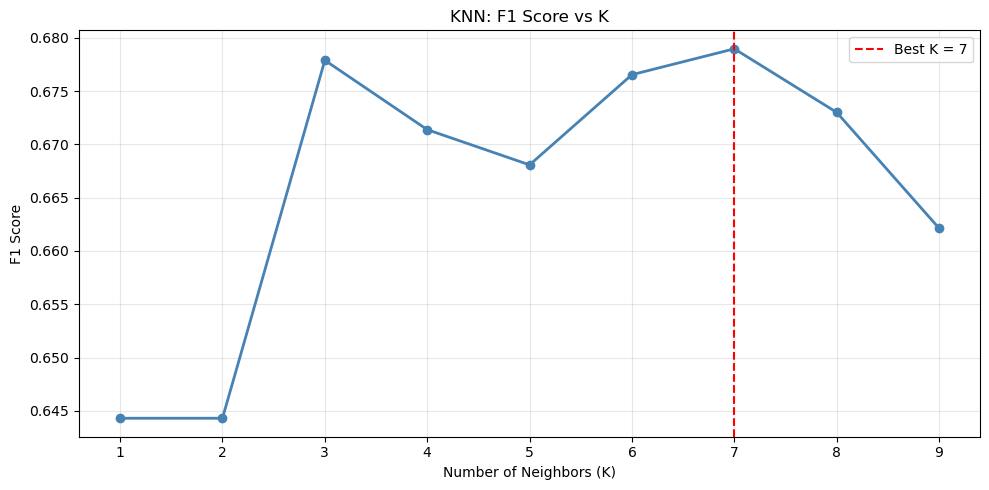

In [49]:
# Tune to find the best number of neighbors (K)
from sklearn.metrics import f1_score

k_values = range(1, 10)
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train, y_train_multi)
    y_pred = knn.predict(X_test)
    f1_scores.append(f1_score(y_test_multi, y_pred, average='macro'))

best_k = k_values[f1_scores.index(max(f1_scores))]
best_f1 = max(f1_scores)
print(f"best F1 score = {best_f1}")

# K vs F1 Score
plt.figure(figsize=(10, 5))
plt.plot(k_values, f1_scores, 'o-', color='steelblue', linewidth=2, markersize=6)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('F1 Score')
plt.title('KNN: F1 Score vs K')
plt.grid(True, alpha=0.3)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
from sklearn.neighbors import KNeighborsClassifier

# set n_neighbors = 7
knn_model = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn_model.fit(X_train, y_train_multi)
y_pred_knn = knn_model.predict(X_test)

knn_performance = evaluate_multiclass_model("KNN", y_test_multi, y_pred_knn)

 KNN
Accuracy              : 0.6813

F1 Score (Macro)      : 0.6790
F1 Score (Micro)      : 0.6813
F1 Score (Weighted)   : 0.6839

Precision (Macro)     : 0.6849
Recall (Macro)        : 0.6789

 Per-Class Performance:
   Medium: Precision=0.5725, Recall=0.6639, F1=0.6148
   High: Precision=0.8880, Recall=0.7351, F1=0.8043
   Very Low: Precision=0.7229, Recall=0.7792, F1=0.7500
   Low: Precision=0.5563, Recall=0.5374, F1=0.5467


### Decision Trees

Unlike Logistic Regression or SVM, Decision Trees don't need One‑vs‑Rest or One‑vs‑One tricks. They handle multiple classes directly.

In [60]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth= 10, criterion='gini', random_state=42) 
dt_model.fit(X_train, y_train_multi)
y_pred_dt = dt_model.predict(X_test)

dt_performance = evaluate_multiclass_model("Decision Tree", y_test_multi, y_pred_dt)

 Decision Tree
Accuracy              : 0.7128

F1 Score (Macro)      : 0.7101
F1 Score (Micro)      : 0.7128
F1 Score (Weighted)   : 0.7156

Precision (Macro)     : 0.7126
Recall (Macro)        : 0.7100

 Per-Class Performance:
   Medium: Precision=0.5882, Recall=0.6723, F1=0.6275
   High: Precision=0.8601, Recall=0.8146, F1=0.8367
   Very Low: Precision=0.7887, Recall=0.7273, F1=0.7568
   Low: Precision=0.6133, Recall=0.6259, F1=0.6195


I increased max_depth and F1 Score did'nt change significantly , it would just be overfit.
and when decreased the max_depth, F1 Score decreased.. underfitting.

## Boosting

The target labels are strings (High, Medium, Low, Very Low). I will use LabelEncoder to convert them to integers (0–3) before training

In [62]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train_multi)
y_test_encoded = label_encoder.transform(y_test_multi)

mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print(mapping)

{'High': 0, 'Low': 1, 'Medium': 2, 'Very Low': 3}


### XGBoost

In [64]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 995.9 kB/s eta 0:01:42
   ---------------------------------------- 0.8/101.7 MB 930.8 kB/s eta 0:01:49
   ---------------------------------------- 0.8/101.7 MB 930.8 kB/s eta 0:01:49
   ---------------------------------------- 1.0/101.7 MB 922.5 kB/s eta 0:01:50
    --------------------------------------- 1.3/101.7 MB 946.7 kB/s eta 0:01:47
    --------------------------------------- 1.6/101.7 MB 947.2 kB/s eta 0:01:46
    --------------------------------------- 1.6/101.7 MB 947.2 kB/s eta 0:01:46
    --------------------------------------- 1.8/101.7 MB 944.4 kB/s eta 0:01:46
    --------------------------------------- 2.1/101.7 MB 951.7 kB/s eta 0:01

In [69]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=50)
xgb_model.fit(X_train, y_train_encoded)
y_pred_xgb = xgb_model.predict(X_test)

xgb_performance = evaluate_multiclass_model("XGBoost", y_test_encoded, y_pred_xgb)

 XGBoost
Accuracy              : 0.7986

F1 Score (Macro)      : 0.7923
F1 Score (Micro)      : 0.7986
F1 Score (Weighted)   : 0.7984

Precision (Macro)     : 0.7931
Recall (Macro)        : 0.7922

 Per-Class Performance:
   0: Precision=0.8734, Recall=0.9139, F1=0.8932
   1: Precision=0.7152, Recall=0.7347, F1=0.7248
   2: Precision=0.7069, Recall=0.6891, F1=0.6979
   3: Precision=0.8767, Recall=0.8312, F1=0.8533


Tuning the hyperparameters using GridSearchCV

In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 150]
}

xgb_model = XGBClassifier(random_state=42)
grid = GridSearchCV(xgb_model, param_grid, cv=3, scoring='f1_macro')
grid.fit(X_train, y_train_encoded)

best_params = grid.best_params_

xgb_model = grid.best_estimator_
xgb_model.fit(X_train, y_train_encoded)
y_pred_xgb = xgb_model.predict(X_test)

print(best_params)
xgb_performance = evaluate_multiclass_model("XGBoost", y_test_encoded, y_pred_xgb)

{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100}
 XGBoost
Accuracy              : 0.7986

F1 Score (Macro)      : 0.7945
F1 Score (Micro)      : 0.7986
F1 Score (Weighted)   : 0.7992

Precision (Macro)     : 0.7945
Recall (Macro)        : 0.7948

 Per-Class Performance:
   0: Precision=0.9007, Recall=0.9007, F1=0.9007
   1: Precision=0.7095, Recall=0.7143, F1=0.7119
   2: Precision=0.7097, Recall=0.7395, F1=0.7243
   3: Precision=0.8581, Recall=0.8247, F1=0.8411


### LightGBM


In [75]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 755.7 kB/s eta 0:00:02
   --------------------- ------------------ 0.8/1.5 MB 863.5 kB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 863.5 kB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 843.5 kB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 862.6 kB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 845.1 kB/s eta 0:00:00


 - **learning_rate:** Controls how much each tree corrects errors from previous trees.
 - **max_depth:** Limits tree complexity.

In [85]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(learning_rate=0.1, max_depth=6, random_state=42)
lgb_model.fit(X_train, y_train_encoded)
y_pred_lgb = lgb_model.predict(X_test)

lgb_performance = evaluate_multiclass_model("LightGBM", y_test_encoded, y_pred_lgb)
print(f"F1 score (macro) = {lgb_performance['F1_Macro']}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4555
[LightGBM] [Info] Number of data points in the train set: 2283, number of used features: 127
[LightGBM] [Info] Start training from score -1.389365
[LightGBM] [Info] Start training from score -1.417888
[LightGBM] [Info] Start training from score -1.387609
[LightGBM] [Info] Start training from score -1.351430
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

c:\Users\kavoshrayan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


- LightGBM shows thousands of warnings ("No further splits with positive gain"), indicating difficulty finding useful splits. This suggests the data may be too small or features lack discriminative power for tree-based models.

### AdaBoost

**estimator** = The base estimator from which the boosted ensemble is built.

In [88]:
!pip install --upgrade scikit-learn

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

base_estimator = DecisionTreeClassifier(max_depth=1)  # Decision Stump

ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,        
    learning_rate=1.0,       
    random_state=42
)

ada_model.fit(X_train, y_train_encoded)
y_pred_ada = ada_model.predict(X_test)

ada_performance = evaluate_multiclass_model("AdaBoost", y_test_encoded, y_pred_ada)

 AdaBoost
Accuracy              : 0.7391

F1 Score (Macro)      : 0.7352
F1 Score (Micro)      : 0.7391
F1 Score (Weighted)   : 0.7410

Precision (Macro)     : 0.7384
Recall (Macro)        : 0.7357

 Per-Class Performance:
   0: Precision=0.9023, Recall=0.7947, F1=0.8451
   1: Precision=0.6571, Recall=0.6259, F1=0.6411
   2: Precision=0.6103, Recall=0.6975, F1=0.6510
   3: Precision=0.7840, Recall=0.8247, F1=0.8038


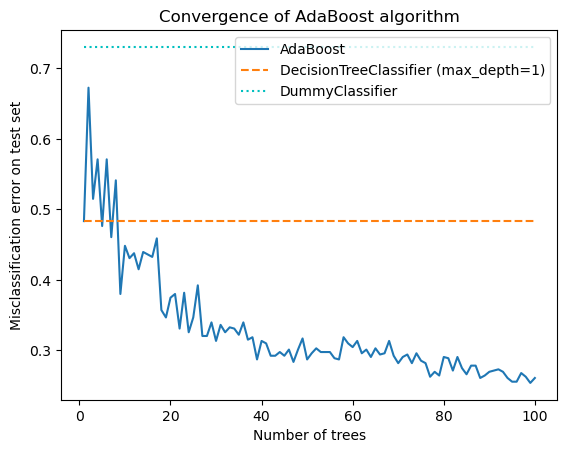

In [100]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier


def misclassification_error(y_true, y_pred):
    return 1 - accuracy_score(y_true, y_pred)

weak_learner = DecisionTreeClassifier(max_depth=1)
weak_learner.fit(X_train, y_train_encoded)
y_pred_weak = weak_learner.predict(X_test)
weak_learners_misclassification_error = 1 - accuracy_score(y_test_encoded, y_pred_weak)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train_encoded)
y_pred_dummy = dummy.predict(X_test)
dummy_classifiers_misclassification_error = 1 - accuracy_score(y_test_encoded, y_pred_dummy)

boosting_errors = pd.DataFrame(
    {
        "Number of trees": range(1, 101),
        "AdaBoost": [
            misclassification_error(y_test_encoded, y_pred)
            for y_pred in ada_model.staged_predict(X_test)
        ],
    }
).set_index("Number of trees")


ax = boosting_errors.plot()
ax.set_ylabel("Misclassification error on test set")
ax.set_title("Convergence of AdaBoost algorithm")

plt.plot(
    [boosting_errors.index.min(), boosting_errors.index.max()],
    [weak_learners_misclassification_error, weak_learners_misclassification_error],
    color="tab:orange",
    linestyle="dashed",
)

plt.plot(
    [boosting_errors.index.min(), boosting_errors.index.max()],
    [dummy_classifiers_misclassification_error, dummy_classifiers_misclassification_error],
    color="c",
    linestyle="dotted",
)

plt.legend(["AdaBoost", "DecisionTreeClassifier (max_depth=1)", "DummyClassifier"], loc=1)
plt.show()

The plot shows the missclassification error on the test set after each boosting iteration. We see that the error of the boosted trees converges to an error of around 0.2 after 100 iterations, indicating a significantly higher accuracy compared to a single tree, as illustrated by the dashed line in the plot.

### CatBoost


In [103]:
!pip install catboost

ERROR: Could not find a version that satisfies the requirement catboost (from versions: none)
ERROR: No matching distribution found for catboost


In [102]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=100,           
    learning_rate=0.1,
    depth=6,                 
    loss_function='MultiClass',  
    eval_metric='F1',
    random_seed=42,
    verbose=50               
)

cat_model.fit(
    X_train, y_train_encoded,
    eval_set=(X_test, y_test_encoded),
    verbose=50,
    plot=True
)

y_pred_cat = cat_model.predict(X_test)
y_pred_cat = y_pred_cat.astype(int)  

cat_performance = evaluate_multiclass_model("CatBoost", y_test_encoded, y_pred_cat)

ModuleNotFoundError: No module named 'catboost'

##### Comparing final models

In [ ]:
models_results ={}

models_results["SVM (Linear , OVR)"] = svm_performance
models_results["SVM (RBF , OVR)"] = svm_rbf_performance
models_results["Logisitic Regression (OVR)"] = lr_ovr_performance
models_results["Logisitic Regression (Multinomial)"] = lr_multi_performance
models_results["KNN"] = knn_performance
models_results["Decision Tree"] = dt_performance
models_results["XGBoost"] = xgb_performance
models_results["LightGBM"] = lgb_performance
models_results["AdaBoost"] = ada_performance 

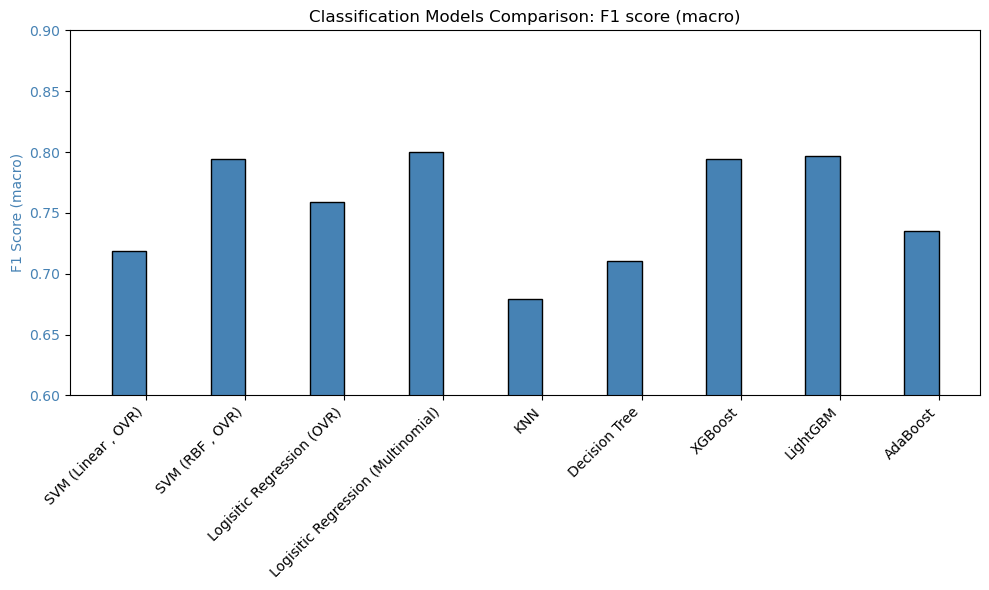

In [117]:
results_df = pd.DataFrame(models_results).T

models = results_df.index.tolist()
f1_macro_scores = results_df['F1_Macro'].values

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(x - width/2, f1_macro_scores, width, label='R²', color='steelblue', edgecolor='black')
ax.set_ylabel('F1 Score (macro)', color='steelblue')
ax.set_ylim(0.6, 0.9)
ax.tick_params(axis='y', labelcolor='steelblue')


ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_title('Classification Models Comparison: F1 score (macro)')
fig.tight_layout()
plt.show()

## Discussion Question:

**1. Choose the best multiclass-classification metric for your dataset and justify.**

I choose F1 Macro as the primary evaluation metric even though the dataset is balanced. F1 Macro gives equal weight to every class, revealing that the model performs worse on Low (F1=0.72) and Medium (F1=0.70) classes despite doing well on High and Very Low. Accuracy would hide this weakness. For real‑world deployment, balanced performance across all classes matters more than overall accuracy.


**2. Explain how KNN and Decision Trees can be extended to multi-label classification problems.**

#### KNN for Multi-Label:

ML-KNN extends KNN to multi-label by finding k nearest neighbors, counting for each label how many neighbors have that label, and assigning labels whose count exceeds a threshold (like: k/2). The output is a binary vector (like: [1,0,1]). This method naturally captures label interactions because neighbors carry multiple labels simultaneously.


#### Decision Tree for Multi-Label:

Decision trees can be extended to multi-label classification in several ways.

The most common approach is Binary Relevance, where a separate decision tree is trained for each label, treating the problem as multiple independent binary classification tasks; this method is simple but ignores correlations among labels. 

Another method is Label Powerset, which converts each unique combination of labels into a single “super-class,” allowing a regular decision tree to be trained, but this can become inefficient when many label combinations exist.

A more advanced strategy involves adapting the tree-learning algorithm itself so that it evaluates splits using multi-label impurity measures (such as averaging the Gini impurity or entropy across all labels). In this approach, each node stores a distribution over all labels, and predictions are made by thresholding these probabilities. 

**3. Suppose we have a multi-label classifi cation problem in football, where each player can belong to some of these 4 classes:**

**Class 1: The player has played for the national team before**

**Class 2: The player has a history of heart problems**

**Class 3: The player had previous knee injuries**

**Class 4: The player has been a team captain in the past**

**What accuracy metric would you use to best evaluate a classifi cation algorithm that predicts the above
classes based on data from each player, and why?**




For this multi-label football problem, **Hamming Loss** is the best metric. It calculates the fraction of incorrect label predictions across all labels and samples. It doesn't penalize a single mistake too harshly.

Since the four labels are conceptually independent (playing in national team is independent of heart problems or knee injury or being a team captain), evaluating each label separately is appropriate. 




$N $= number of samples.

$L $= number of labels


Hamming Loss = $\frac{1}{N \times L} \sum_{i = 1}^N \sum_{j = 1}^L1(y_{ij} \neq \hat y_{ij})$

- if Hamming Loss ~ 0 => good classification